## Synthetic scene setup

In [1]:
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image
from ivt.sampling import sample_sphere
import torch

In [2]:
scene = Scene()

# material
diffuse = read_image("assets/wood_olive/wood_olive_wood_olive_diffuse.png")
specular = read_image("assets/wood_olive/wood_olive_wood_olive_specular.png")
roughness = read_image("assets/wood_olive/wood_olive_wood_olive_roughness.png")

scene.set('mat', MicrofacetBRDF(diffuse, specular, roughness))
scene.set('mesh1', Mesh.from_file("assets/meshes/sphere.obj", 'mat')) # surface to reconstruct
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('collocated', {'intensity':1}))
# scene.set('cam1', PerspectiveCamera.from_lookat(fov=40, origin=(1,0.5,0), target=(0,0,0), up=(0,1,0))) # camera

# randomly generate cameras
num_sensors = 50
fov = 40
radius = 1
target = (0,0,0)
up = (0,1,0)
for i, origin in enumerate(sample_sphere(num_sensors, radius, 'fibonacci')):
    scene.set(f'sensor {i}', PerspectiveCamera.from_lookat(fov, origin, target, up))

In [3]:
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 16,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't update changes in spp, workaround here to render a higher spp target image
I_t = torch.stack([renderer(scene, sensor_ids=range(num_sensors)) for _ in range(8)]).mean(axis=0)
# I_t = renderer(scene)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


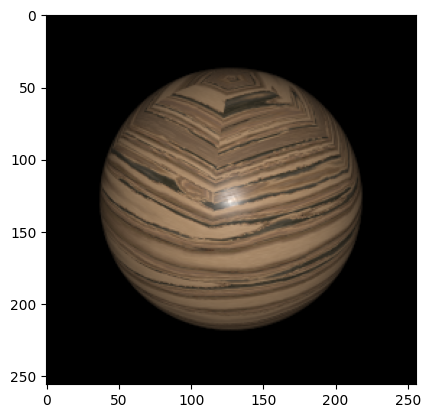

In [4]:
# Visualize the target Image
from matplotlib import pyplot as plt
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
showimg(I_t[10])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


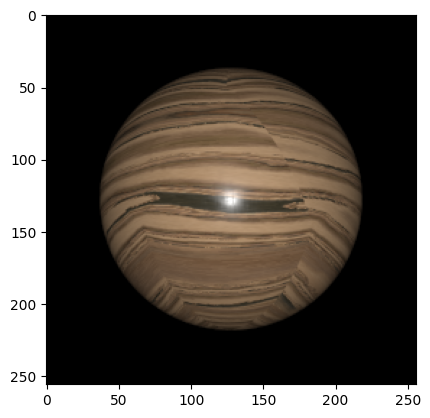

In [5]:
showimg(I_t[33])

## Showing Highlight

In [10]:


scene['mat']['s'] = torch.zeros_like(scene['mat']['s'])
scene['mat']['r'] = torch.zeros_like(scene['mat']['r'])
I_d = torch.stack([renderer(scene, sensor_ids=range(num_sensors)) for _ in range(8)]).mean(axis=0)

(array([2.000000e+00, 1.000000e+01, 3.000000e+01, 1.690000e+02,
        8.900000e+02, 6.244000e+03, 7.897900e+04, 9.005195e+06,
        4.333740e+05, 9.897000e+04, 4.775600e+04, 2.901400e+04,
        2.000500e+04, 1.516900e+04, 1.151700e+04, 9.589000e+03,
        7.816000e+03, 6.759000e+03, 6.112000e+03, 4.708000e+03,
        4.687000e+03, 3.607000e+03, 3.133000e+03, 3.024000e+03,
        2.703000e+03, 2.262000e+03, 2.065000e+03, 2.001000e+03,
        1.515000e+03, 1.299000e+03, 1.198000e+03, 1.416000e+03,
        1.187000e+03, 1.181000e+03, 9.690000e+02, 8.400000e+02,
        7.960000e+02, 7.730000e+02, 6.300000e+02, 6.240000e+02,
        5.580000e+02, 7.600000e+02, 6.380000e+02, 4.460000e+02,
        3.910000e+02, 3.870000e+02, 3.620000e+02, 3.980000e+02,
        4.240000e+02, 3.240000e+02, 3.490000e+02, 2.860000e+02,
        3.460000e+02, 3.310000e+02, 2.940000e+02, 2.280000e+02,
        2.840000e+02, 2.290000e+02, 2.370000e+02, 2.000000e+02,
        1.790000e+02, 1.590000e+02, 2.08

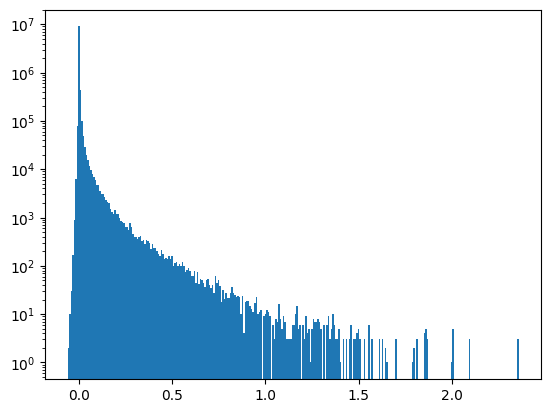

In [58]:
hl = I_t - I_d
# showimg(hl.abs()[1]*10)
a = hl.cpu().flatten().numpy()
plt.hist(a, bins=300, log=True)

In [49]:
hl[0].cpu().flatten().numpy().max()

0.87734604

In [ ]:
# showimg(I_t[9])

## Performance Tests

In [5]:
from time import perf_counter

# for _ in range(20):
#     t0 = perf_counter()
#     renderer(scene, sensor_ids=[10])
#     t1 = perf_counter()
#     print("time: ", t1-t0)

# warm up
renderer(scene, sensor_ids=range(num_sensors))
    
t0 = perf_counter()
for _ in range(10):
    i1 = renderer(scene, sensor_ids=range(1))
t1 = perf_counter()
print("time: ", t1-t0)

time:  0.20699749999999995


## Noise Distribution

In [7]:
I_t_noisy = renderer(scene, sensor_ids=range(num_sensors))

0.0031522098
1997998 0.00014038936199138144
1997998 0.00014038902
42883 0.0016436116876410631
42883 0.0016429068
65143 0.0022838049858747854
65143 0.0022832039
75856 0.0029040103270768424
75856 0.002903518
79586 0.0034048416961328424
79586 0.0034043966
81384 0.003858699339016522
81384 0.0038585586
82267 0.00415212668546151
82267 0.004152094
80737 0.004463467630438885
80737 0.004463418
79578 0.0047015294576097984
79578 0.0047012437
75856 0.004846176339913978
75856 0.0048461356
70543 0.005184150601715727
70543 0.0051841387
64734 0.005341522780040664
64734 0.0053414833
58094 0.005658461467153807
58094 0.005658447
51670 0.0059250375395363195
51670 0.005925021
45033 0.0062076538832319846
45033 0.0062076086
39114 0.006440228114903361
39114 0.006439905
34544 0.006670550660837304
34544 0.006670486
30266 0.006645728998108474
30266 0.006645693
28059 0.006678743222919697
28059 0.006678029
25305 0.006522458303775561
25305 0.006522228
22938 0.006398915316203124
22938 0.0063988687
20276 0.0062185723

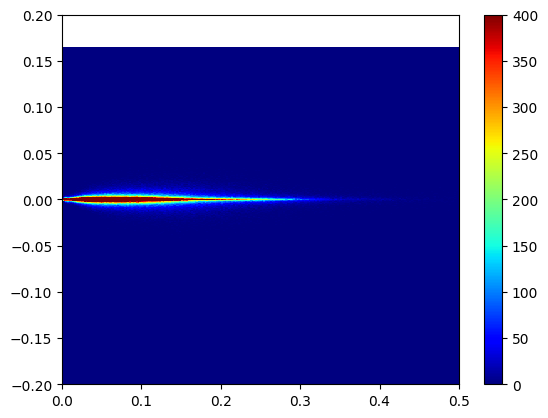

In [35]:
import numpy
truth = I_t[:,:,:,1].flatten().cpu().numpy()
noisy = I_t_noisy[:,:,:,1].flatten().cpu().numpy()
noise = noisy - truth
# plt.scatter(truth, noise, s=0.1)
# plt.x_lim(0, 1)

plt.hist2d(truth, noise, bins=(1222, 1222), cmap=plt.cm.jet, vmax=400)
plt.xlim(0,0.5)
plt.ylim(-0.2, 0.2)
plt.colorbar()

print(numpy.std(noise))
import math

n_range = 100
devs = []
for i in range(n_range):
    st = 1.0/n_range * i
    ed = 1.0/n_range * (i+1)
    a = noise[(st <= truth) & (truth < ed)]
    print(len(a), math.sqrt((a**2).mean()))
    devs.append(numpy.std(a))
    print(len(a), numpy.std(a))

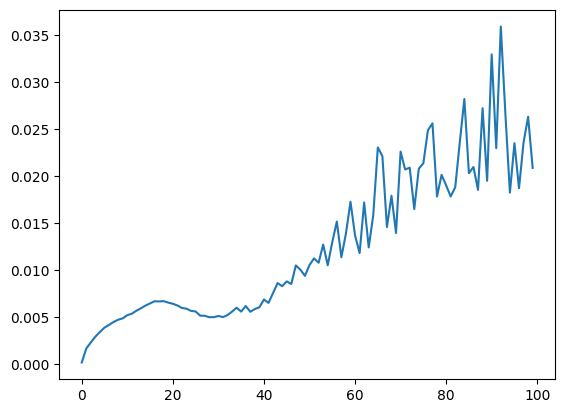

In [36]:
plt.plot(devs)

In [31]:
# print memory usage
import os
import psutil

def print_memory_usage():
    process = psutil.Process(os.getpid())
    memory_info = process.memory_info()
    print(f"Memory used: {memory_info.rss / 1024 ** 2} MB")

print_memory_usage()

Memory used: 2071.6875 MB


## Optimize

In [8]:
from ivt.model import Model
class MicrofacetNaive(Model):

    def __init__(
        self,
        scene,
        mat_id,
        d_min=0.0,
        d_max=1.0,
#         s_min=0.0,
#         s_max=1.0,
        r_min=0.0,
        r_max=1.0,
        d_lr=1e-2,
        s_lr=1e-2,
        r_lr=1e-2,
        t_res=None,
        optimizer_kwargs={},
    ):

        super().__init__(scene)

        self.brdf = self.scene[mat_id]

        if isinstance(t_res, int):
            self.brdf['d'] = torch.ones((t_res, t_res, 3), dtype=ftype, device=device) * 0.5
#             self.brdf['s'] = torch.ones((t_res, t_res, 3), dtype=ftype, device=device) * 0.5
            self.brdf['r'] = torch.ones((t_res, t_res, 1), dtype=ftype, device=device) * 0.5

        self._d_v_min = d_min
#         self._s_v_min = s_min
        self._r_v_min = r_min

        self._d_v_span = d_max - d_min
#         self._s_v_span = s_max - d_min
        self._r_v_span = r_max - d_min

        self._d_data = torch.logit(torch.clip(
            self.brdf['d'], 1e-5, 1-1e-5)).requires_grad_()
#         self._s_data = torch.logit(torch.clip(
#             self.brdf['s'], 1e-5, 1-1e-5)).requires_grad_()
        self._r_data = torch.logit(torch.clip(
            self.brdf['r'], 1e-5, 1-1e-5)).requires_grad_()

        self.optimizer = torch.optim.Adam(
            [self._d_data, \
#              self._s_data,
             self._r_data], **optimizer_kwargs)

        self.optimizer = torch.optim.Adam([
            {"params": self._d_data, "lr": d_lr},
#             {"params": self._s_data, "lr": s_lr},
            {"params": self._r_data, "lr": r_lr},
        ], **optimizer_kwargs)

    def zero_grad(self):
        self.optimizer.zero_grad()

    def set_data(self):
        self.brdf['d'] = torch.sigmoid(self._d_data) * self._d_v_span + self._d_v_min
#         self.brdf['s'] = torch.sigmoid(self._s_data) * self._s_v_span + self._s_v_min
        self.brdf['r'] = torch.sigmoid(self._r_data) * self._r_v_span + self._r_v_min

    def step(self):
        self.optimizer.step()

    def get_results(self):
        results = {
            'd': self.brdf['d'].detach(),
#             's': self.brdf['s'].detach(),
            'r': self.brdf['r'].detach(),
        }
        return results

    def write_results(self, result_path):
        result_path = Path(result_path)
        result_path.mkdir(parents=True, exist_ok=True)

        results = self.get_results()
        write_image(result_path / f"diffuse.exr", results['d'])
#         write_image(result_path / f"specular.exr", results['s'])
        write_image(result_path / f"roughness.exr", results['r'])

In [9]:
from ivt.model import MultiOpt
from ivt.io import ftype, device
opt_sensor_ids = torch.arange(num_sensors, dtype=torch.int64)
batch_size = 1
model = MicrofacetNaive(scene, mat_id='mat', d_lr=5e-2, t_res=1024)

In [10]:
from tqdm.notebook import tqdm
from ivt.loss import l1_loss

loss_record = []

opt_imgs = []

for epoch in tqdm(range(6000)):
    # Randomly shuffle sensors
    sensor_perm = opt_sensor_ids[torch.randperm(num_sensors)]
    sensor_ids = sensor_perm[0:1]
    
    tar_images = torch.stack([I_t[id] for id in sensor_ids], dim=0)

    model.zero_grad()
    model.set_data()
    scene.configure()

#     t0 = time()

    opt_images = renderer(scene, sensor_ids=sensor_ids, integrator_id=0)
    if epoch%200 == 199:
        print(loss)
        opt_imgs.append(opt_images)
    
#     showimg(opt_images)
#     t1 = time()
#     render_time = t1 - t0
# 
#     t0 = time()

    image_loss = l1_loss(tar_images, opt_images)
#     image_loss = ((tar_images - opt_images)**2).mean()
    reg_loss = model.get_regularization()
    loss = image_loss + reg_loss

    loss.backward()
    model.step()

#     t1 = time()
#     opt_time = t1 - t0

    loss_record.append(loss.item())

  0%|          | 0/6000 [00:00<?, ?it/s]

tensor(0.0029, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0025, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0017, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0019, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0017, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0020, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0017, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0019, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0018, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.0019, device='cuda:0', grad_fn=<AddBack

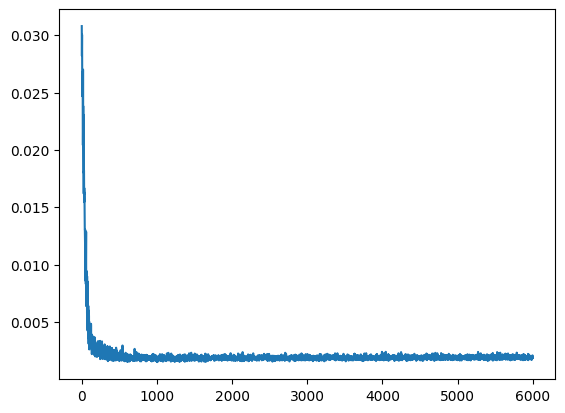

In [11]:


fig, ax = plt.subplots()

# Set y-axis to logarithmic scale
ax.spines['bottom'].set_position('zero')
ax.plot(loss_record)

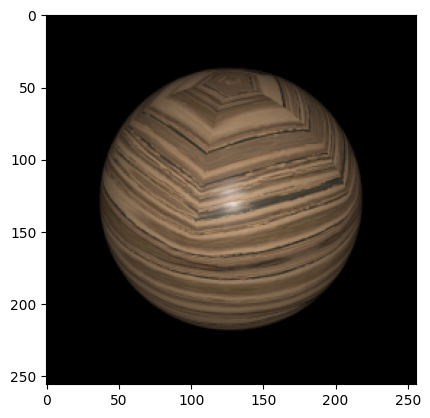

In [18]:
showimg(I_t[9])

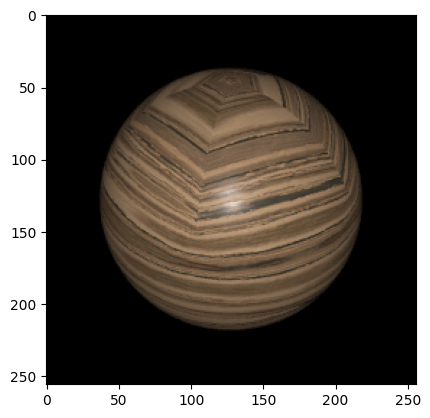

In [13]:
showimg(opt_images)

In [62]:
from pathlib import Path
model.write_results("results/1")

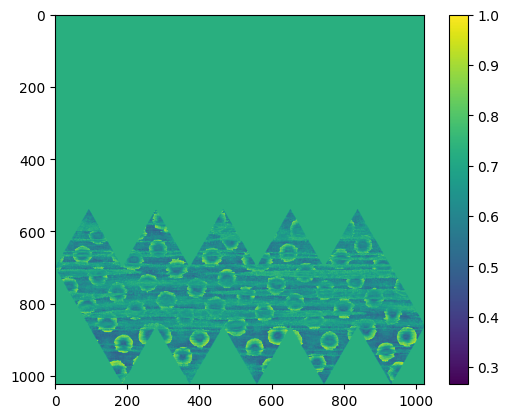

In [20]:
showimg(scene['mat']['r'])
plt.colorbar()

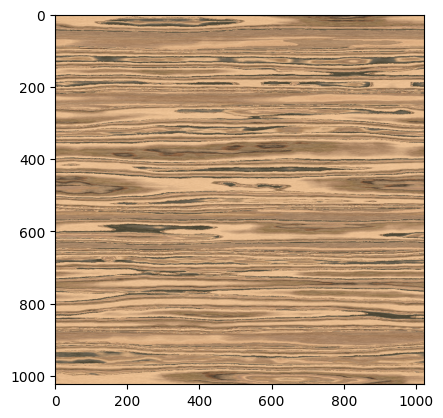

In [17]:
showimg(scene['mat']['d'])

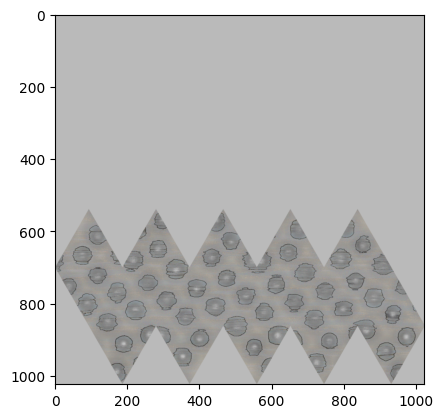

In [68]:
showimg(scene['mat']['s'])

In [27]:
import sys

# These are the usual ipython objects, including this one you are creating
ipython_vars = ['In', 'Out', 'exit', 'quit', 'get_ipython', 'ipython_vars']

# Get a sorted list of the objects and their sizes
sorted([(x, sys.getsizeof(globals().get(x))) for x in dir() if not x.startswith('_') and x not in sys.modules and x not in ipython_vars], key=lambda x: x[1], reverse=True)

[('diffuse', 12583056),
 ('specular', 12583056),
 ('roughness', 4194448),
 ('loss_record', 48456),
 ('MicrofacetNaive', 1192),
 ('DiffuseBRDF', 1064),
 ('EnvironmentLight', 1064),
 ('HDRFilm', 1064),
 ('Integrator', 1064),
 ('Mesh', 1064),
 ('MicrofacetBRDF', 1064),
 ('Model', 1064),
 ('MultiOpt', 1064),
 ('PerspectiveCamera', 1064),
 ('Scene', 1064),
 ('opt_imgs', 336),
 ('l1_loss', 136),
 ('open', 136),
 ('read_image', 136),
 ('read_mesh', 136),
 ('sample_sphere', 136),
 ('showimg', 136),
 ('write_image', 136),
 ('ftype', 88),
 ('I_t', 72),
 ('image_loss', 72),
 ('loss', 72),
 ('opt_images', 72),
 ('opt_sensor_ids', 72),
 ('origin', 72),
 ('plt', 72),
 ('reg_loss', 72),
 ('sensor_ids', 72),
 ('sensor_perm', 72),
 ('tar_images', 72),
 ('target', 64),
 ('up', 64),
 ('device', 53),
 ('ax', 48),
 ('fig', 48),
 ('model', 48),
 ('renderer', 48),
 ('scene', 48),
 ('batch_size', 28),
 ('epoch', 28),
 ('fov', 28),
 ('i', 28),
 ('num_sensors', 28),
 ('radius', 28)]